# Nightlights around drug production areas

In [11]:
import pandas as pd

drug = pd.read_excel(
    "../../data/drug_production/Captagon Factories -- All locations 2.xlsx", skiprows=1
)

In [32]:
import pandas as pd
import geopandas as gpd

# Example: column name is "coords" and values look like "36.289023, 37.242741\t"
clean = drug["Coordinates"].astype(str).str.replace("\t", "", regex=False).str.strip()

# If your format is: "lat, lon"
drug[["lat", "lon"]] = (
    clean.str.split(",", n=1, expand=True).apply(lambda s: s.str.strip()).astype(float)
)

# Point(x, y) = Point(lon, lat)
gdf = gpd.GeoDataFrame(
    drug, geometry=gpd.points_from_xy(drug["lon"], drug["lat"]), crs="EPSG:4326"
)

# Create 5 km and 10 km buffers around each point (buffering must be done in a projected CRS)
utm_crs = gdf.estimate_utm_crs()
gdf_utm = gdf.to_crs(utm_crs)
gdf["buffer_5km"] = gdf_utm.geometry.buffer(5_000).to_crs(gdf.crs)
gdf["buffer_10km"] = gdf_utm.geometry.buffer(10_000).to_crs(gdf.crs)

# Optional GeoDataFrames where active geometry is the buffer polygons
gdf_buffer_5km = gdf.set_geometry("buffer_5km")
gdf_buffer_10km = gdf.set_geometry("buffer_10km")

In [185]:
gdf_5km = gdf_buffer_5km[["Zone", "Address", "Factory_size", "Yes_No", "buffer_5km"]]
gdf_10km = gdf_buffer_10km[["Zone", "Address", "Factory_size", "Yes_No", "buffer_10km"]]

# Ensure geometry is the 10km buffer polygon
gdf_10km = gdf_10km.set_geometry("buffer_10km").copy()
gdf_10km.reset_index(drop=True, inplace=True)

# Use spatial index to check overlaps: whether each buffer intersects any other buffer
sidx = gdf_10km.sindex
overlaps = []
for i, geom in enumerate(gdf_10km.geometry):
    # find candidates whose bbox intersects this geometry's bbox
    possible = list(sidx.intersection(geom.bounds))
    # exclude self
    possible = [j for j in possible if j != i]
    found = False
    for j in possible:
        if geom.intersects(gdf_10km.geometry.iloc[j]):
            found = True
            break
    overlaps.append(found)
gdf_10km["overlaps_any"] = overlaps

n_overlapping = int(gdf_10km["overlaps_any"].sum())
total = len(gdf_10km)
print(f"{n_overlapping} of {total} buffers overlap at least one other buffer.")

# Show list of overlapping zones (if any)
overlapping_zones = gdf_10km.loc[gdf_10km["overlaps_any"], "Zone"].tolist()
print("Zones with overlaps:", overlapping_zones)

45 of 53 buffers overlap at least one other buffer.
Zones with overlaps: ['Aleppo, Shikh Najjar', 'Aleppo, Al Nairab ', 'Rural Aleppo, Al Zahraa', 'Aleppo, Al Arqoub', 'Aleppo, Al Muslemiyeh', "Lattakia, Al Sena'ah ", 'Lattakia, Eastern Al Murouj', 'Lattakia, Al Bassa', 'Lattakia, Al Shelfatiyeh', 'Lattakia, Kilmakho ', 'Rural Damascus, Falita', 'Rural Damascus, Falita', 'Rural Damascus, Sarghayah', 'Rural Damascus, Sarghayah', 'Rural Damascus, Assal Al Ward ', 'Rural Damascus, Rankous', 'Rural Damascus, Al Zabadani', 'Rural Damascus, Sidnaya. ', 'Rural Damascus, Maddayah', 'Rural Damascus, Deir Attieh', 'Rural Damascus, Douma', 'Rural Damascus, Al Diemas', 'Rural Damascus, Qara', 'Damascus, Al Sabourah', 'Damascus, Jaramana ', 'Damascus, Sahnaya', 'Homs, Al Qussier ', 'Homs, Arjoun ', 'Daraa, Um Al Mayadiyen', 'Daraa, Al lajat ', 'Daraa, Kharab Al Shahem', 'Daraa, Al Lajat ', 'Daraa, Nassib', 'Daraa, Taiba', 'Daraa, Nawa ', "Daraa, Al Meta'aiyeh", 'Daraa, Tafas ', 'Rural Aleppo, Afrin

In [187]:
# Ensure geometry is the 10km buffer polygon
gdf_5km = gdf_5km.set_geometry("buffer_5km").copy()
gdf_5km.reset_index(drop=True, inplace=True)

# Use spatial index to check overlaps: whether each buffer intersects any other buffer
sidx = gdf_5km.sindex
overlaps = []
for i, geom in enumerate(gdf_5km.geometry):
    # find candidates whose bbox intersects this geometry's bbox
    possible = list(sidx.intersection(geom.bounds))
    # exclude self
    possible = [j for j in possible if j != i]
    found = False
    for j in possible:
        if geom.intersects(gdf_5km.geometry.iloc[j]):
            found = True
            break
    overlaps.append(found)
gdf_5km["overlaps_any"] = overlaps

n_overlapping = int(gdf_5km["overlaps_any"].sum())
total = len(gdf_5km)
print(f"{n_overlapping} of {total} buffers overlap at least one other buffer.")

# Show list of overlapping zones (if any)
overlapping_zones = gdf_5km.loc[gdf_5km["overlaps_any"], "Zone"].tolist()
print("Zones with overlaps:", overlapping_zones)

32 of 53 buffers overlap at least one other buffer.
Zones with overlaps: ['Aleppo, Shikh Najjar', 'Aleppo, Al Nairab ', 'Rural Aleppo, Al Zahraa', 'Aleppo, Al Arqoub', 'Aleppo, Al Muslemiyeh', "Lattakia, Al Sena'ah ", 'Lattakia, Eastern Al Murouj', 'Lattakia, Al Bassa', 'Lattakia, Al Shelfatiyeh', 'Rural Damascus, Falita', 'Rural Damascus, Falita', 'Rural Damascus, Sarghayah', 'Rural Damascus, Sarghayah', 'Rural Damascus, Rankous', 'Rural Damascus, Al Zabadani', 'Rural Damascus, Sidnaya. ', 'Rural Damascus, Maddayah', 'Rural Damascus, Deir Attieh', 'Rural Damascus, Al Diemas', 'Rural Damascus, Qara', 'Damascus, Al Sabourah', 'Homs, Al Qussier ', 'Homs, Arjoun ', 'Daraa, Um Al Mayadiyen', 'Daraa, Al lajat ', 'Daraa, Kharab Al Shahem', 'Daraa, Al Lajat ', 'Daraa, Nassib', 'Daraa, Taiba', "Daraa, Al Meta'aiyeh", 'Daraa, Tafas ', 'Rural Aleppo, Afrin, Al OqaibahAl Oqaibah, the eastern enterance of the village, Al Bassoutah road']


In [26]:
import os
from pathlib import Path
from getpass import getpass
from dotenv import dotenv_values
from blackmarble import BlackMarble

secrets_path = Path.home() / ".config" / "syria-economic-monitor" / "secrets.env"
secrets = dotenv_values(secrets_path)
blackmarble_token = secrets.get("BLACKMARBLE_TOKEN", "").strip()

if not blackmarble_token:
    blackmarble_token = getpass("Enter BlackMarble token (input hidden): ").strip()
    secrets_path.parent.mkdir(parents=True, exist_ok=True)
    secrets_path.write_text(f"BLACKMARBLE_TOKEN={blackmarble_token}\n")
    os.chmod(secrets_path, 0o600)

bm = BlackMarble(token=blackmarble_token)

In [ ]:
monthly_drug_5km = bm.extract(
    gdf_5km, "VNP46A3", pd.date_range("2023-01-01", "2026-01-01", freq="MS")
)

In [36]:
monthly_drug_5km.to_csv("../../data/ntl/drug_production_10km.csv", index=False)

In [88]:
baseline = monthly_drug_5km[monthly_drug_5km["date"] == "2024-12-01"]
baseline = baseline[["Zone", "ntl_sum"]].set_index("Zone").to_dict()["ntl_sum"]

In [ ]:
monthly_drug_5km["baseline_ntl_sum"] = monthly_drug_5km["Zone"].map(baseline)
monthly_drug_5km["pc_change_dec2024"] = (
    100
    * (monthly_drug_5km["ntl_sum"] - monthly_drug_5km["baseline_ntl_sum"])
    / monthly_drug_5km["baseline_ntl_sum"]
)

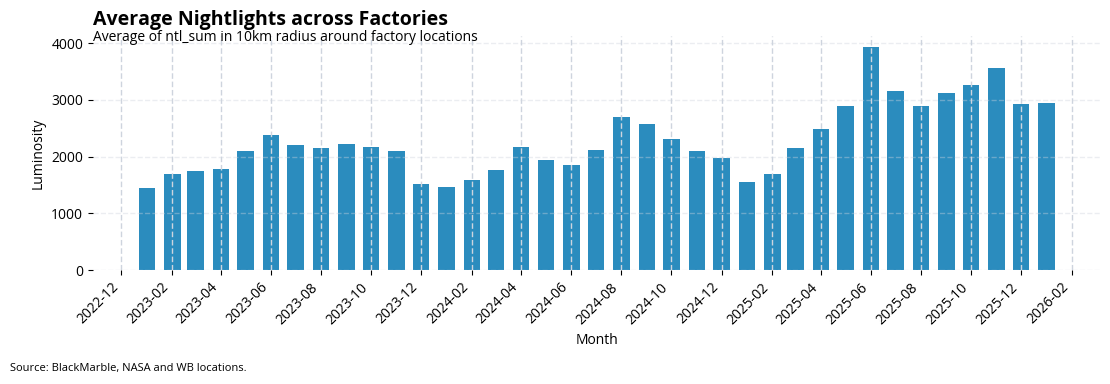

In [98]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import pandas as pd

# prepare aggregated series
if "monthly_drug_5km_agg" not in globals():
    monthly_drug_5km_agg = (
        monthly_drug_5km.groupby("date")["ntl_sum"].mean().reset_index()
    )

# Try to use Open Sans if available, otherwise fall back to a sensible sans
font_family = "Open Sans"
available = {f.name for f in fm.fontManager.ttflist}
if font_family in available:
    plt.rcParams["font.family"] = font_family
else:
    plt.rcParams["font.family"] = ["Open Sans", "DejaVu Sans", "sans-serif"]


def bar_plot(ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 4))
    else:
        fig = ax.figure

    ax.bar(
        monthly_drug_5km_agg["date"],
        monthly_drug_5km_agg["ntl_sum"],
        label="NTL",
        color="#2b8cbe",
        width=20,
    )

    ax.set_ylabel("Luminosity")
    ax.set_xlabel("Month")

    # Left-aligned title
    ax.set_title(
        "Average Nightlights across Factories",
        fontsize=14,
        weight="bold",
        loc="left",
        pad=8,
    )

    # Subtitle placed just below the title (left-aligned)
    ax.text(
        0,
        0.96,
        "Average of ntl_sum in 10km radius around factory locations",
        transform=ax.transAxes,
        fontsize=10,
        va="bottom",
        ha="left",
    )

    # Source/note at the bottom-right
    fig.text(
        0.21,
        0.01,
        "Source: BlackMarble, NASA and WB locations.",
        ha="right",
        fontsize=8,
    )

    # Format x-axis for monthly ticks
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig, ax


# draw
fig, ax = bar_plot()
plt.show()

In [99]:
months_of_interest = [
    "2023-12-01",
    "2023-06-01",
    "2023-11-01",
    "2025-01-01",
    "2025-06-01",
    "2025-12-01",
]
monthly_drug_5km_moi = monthly_drug_5km[
    monthly_drug_5km["date"].isin(months_of_interest)
]

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_40560/3569026627.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  monthly_drug_5km_moi = monthly_drug_5km[monthly_drug_5km['date'].isin(months_of_interest)]


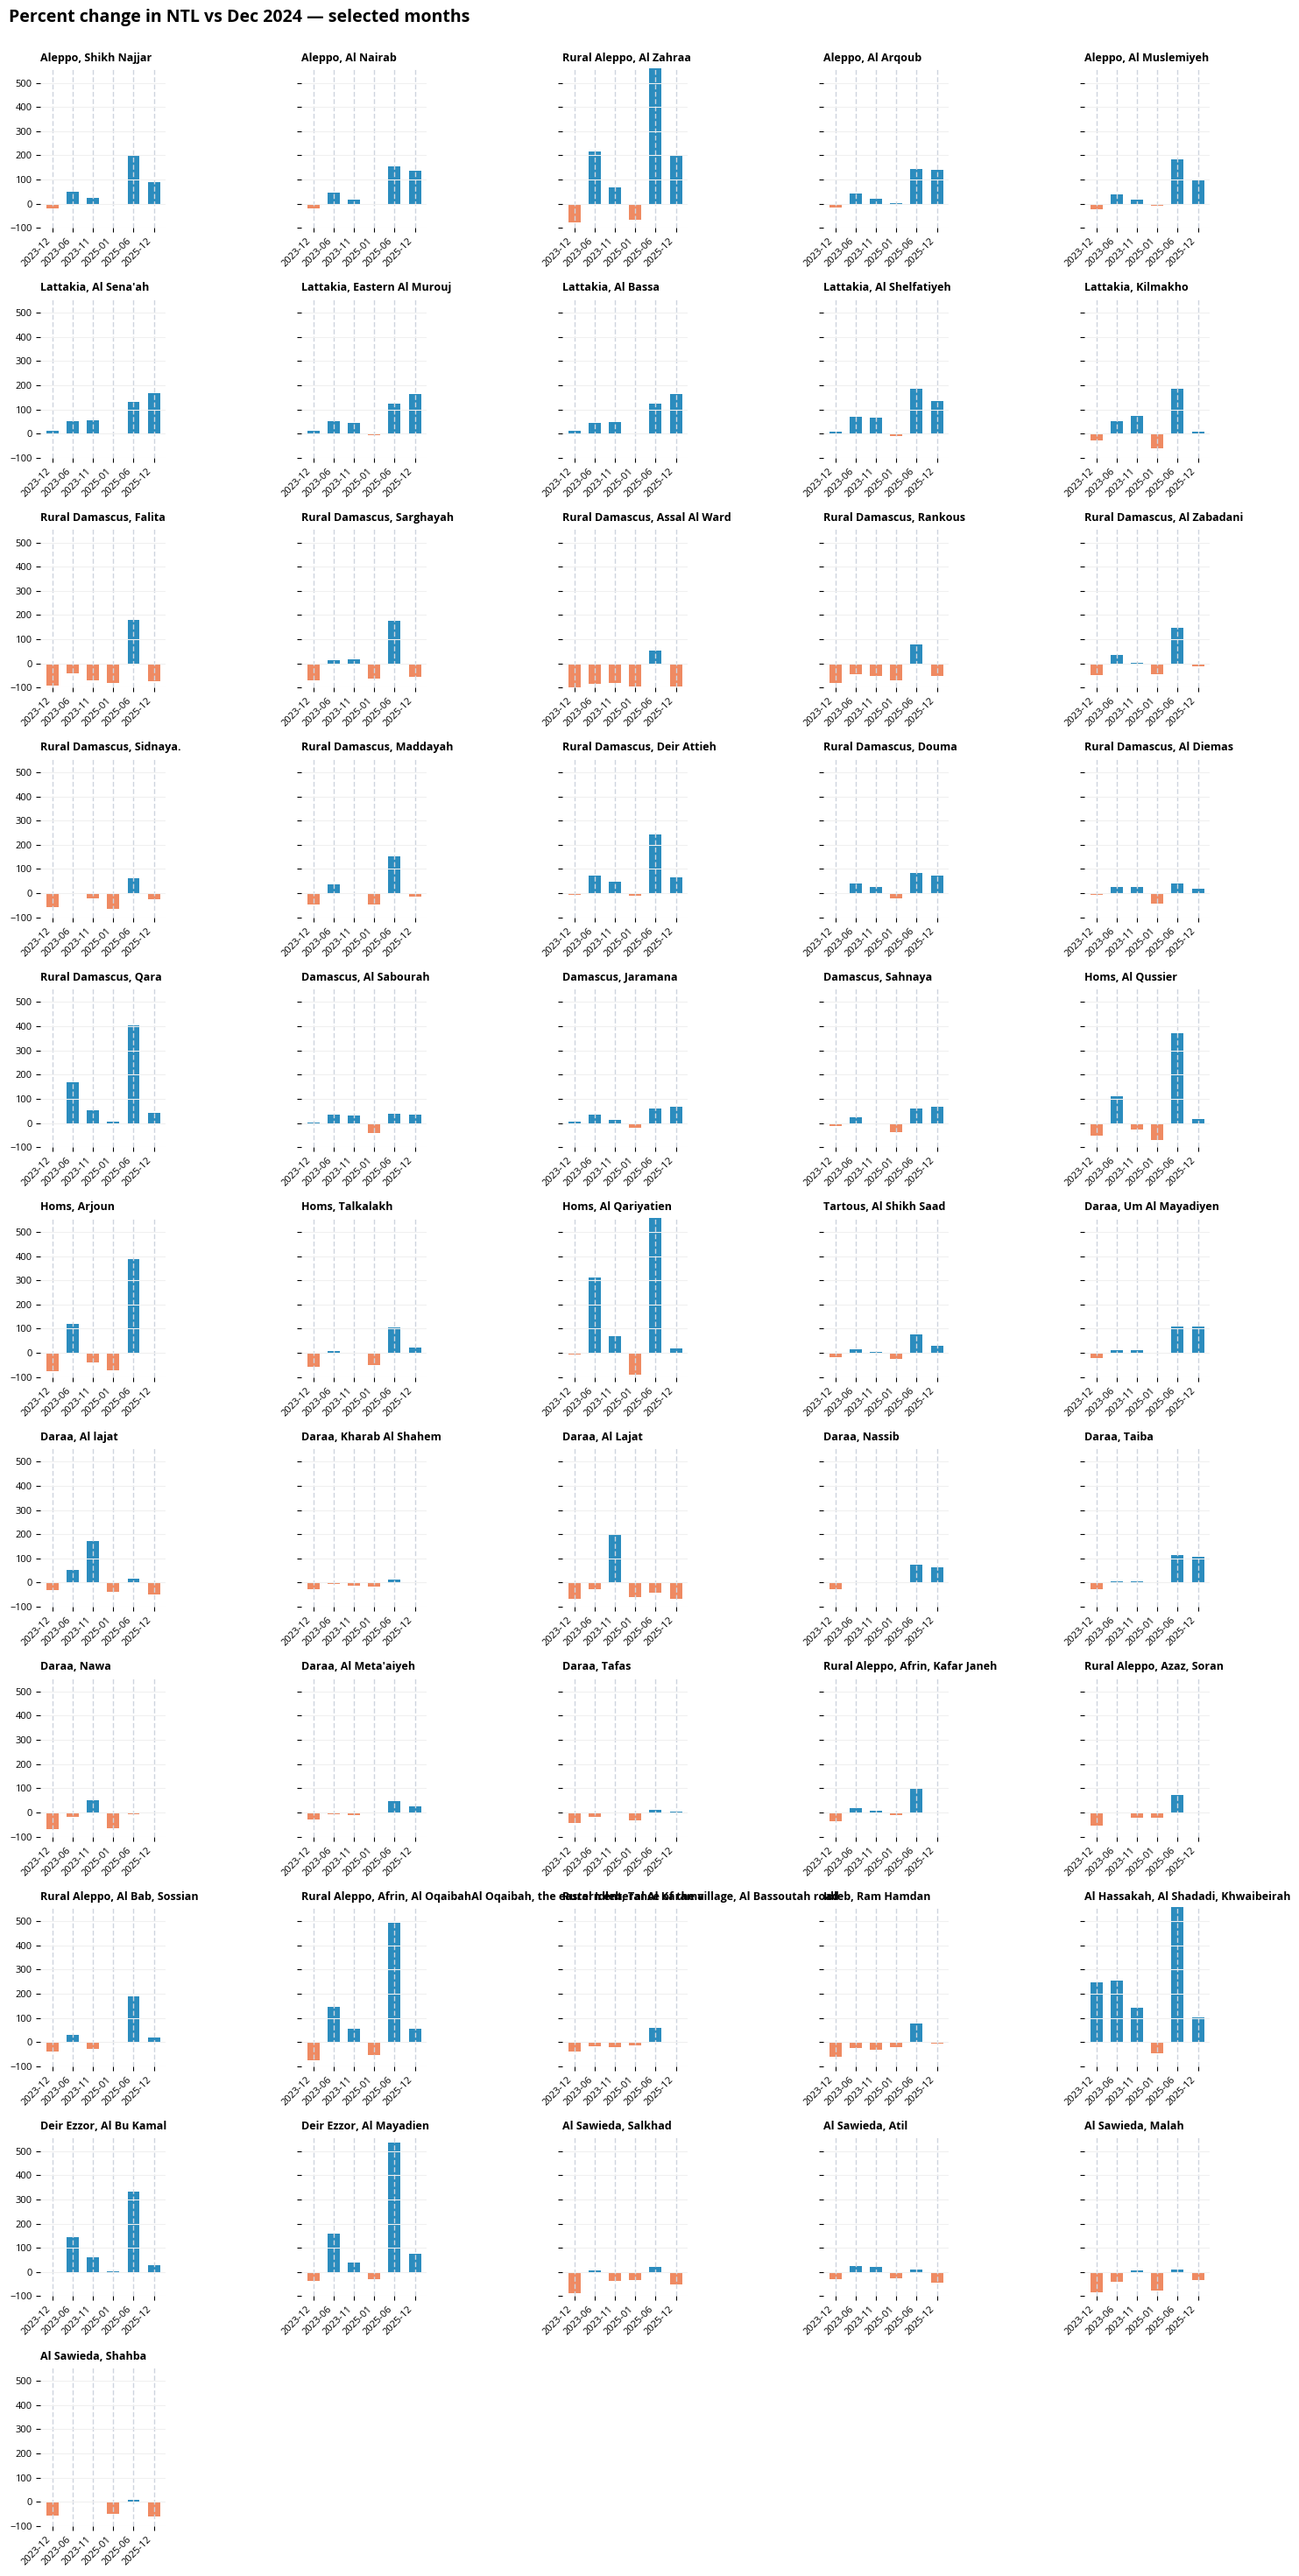

In [177]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd

# months of interest (categorical positions)
months_of_interest = [
    "2023-12-01",
    "2023-06-01",
    "2023-11-01",
    "2025-01-01",
    "2025-06-01",
    "2025-12-01",
]
months_dt = pd.to_datetime(months_of_interest)
months_labels = [d.strftime("%Y-%m") for d in months_dt]
positions = np.arange(len(months_dt))
pos_map = {pd.Timestamp(d): i for i, d in enumerate(months_dt)}

# ensure filtered table exists
if "monthly_drug_5km_moi" not in globals():
    monthly_drug_5km_moi = monthly_drug_5km[monthly_drug_5km["date"].isin(months_dt)]

zones = list(drug["Zone"].unique())
if not zones:
    raise RuntimeError('No zones found in `drug["Zone"]`.')

n_zones = len(zones)
cols = 5
rows = int(np.ceil(n_zones / cols))

# font: try Open Sans then fallback
font_family = "Open Sans"
available = {f.name for f in fm.fontManager.ttflist}
if font_family in available:
    title_fp = fm.FontProperties(family=font_family, weight="bold", size=14)
    label_fp = fm.FontProperties(family=font_family, weight="bold", size=9)
    tick_labelsize = 8
else:
    title_fp = fm.FontProperties(family="DejaVu Sans", weight="bold", size=14)
    label_fp = fm.FontProperties(family="DejaVu Sans", weight="bold", size=9)
    tick_labelsize = 8

# compute robust upper bound for y-axis; lower bound will be fixed at -100
all_vals = monthly_drug_5km_moi["pc_change_dec2024"].dropna()
if not all_vals.empty:
    # use 99th percentile for upper bound to reduce outlier influence
    ymax = np.percentile(all_vals, 99)
    # pad
    ymax += (
        0.05 * (ymax - np.percentile(all_vals, 1))
        if (ymax - np.percentile(all_vals, 1)) != 0
        else ymax * 0.1
    )
    # ensure ymax at least 50
    ymax = max(ymax, 50)
else:
    ymax = 1200

ymin = -100

fig, axes = plt.subplots(
    rows, cols, figsize=(14, rows * 3.0), sharex=False, sharey=True
)
axs = axes.flatten() if hasattr(axes, "flatten") else [axes]

bar_width = 0.6

for idx, zone in enumerate(zones):
    ax = axs[idx]
    df = monthly_drug_5km_moi[monthly_drug_5km_moi["Zone"] == zone].copy()

    # always set x-ticks to the categorical months_of_interest
    ax.set_xticks(positions)
    ax.set_xticklabels(months_labels, rotation=45, ha="right", fontsize=tick_labelsize)

    if df.empty:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", fontsize=9)
        ax.set_title(str(zone), fontproperties=label_fp, loc="left")
        ax.set_ylim(ymin, ymax)
        continue

    # map each row's date to the categorical position
    df["pos"] = df["date"].map(lambda d: pos_map.get(pd.Timestamp(d)))
    df = df.dropna(subset=["pos"])

    # color positives vs negatives
    colors = ["#2b8cbe" if v >= 0 else "#ef8a62" for v in df["pc_change_dec2024"]]

    ax.bar(
        df["pos"],
        df["pc_change_dec2024"],
        width=bar_width,
        color=colors,
        align="center",
    )
    ax.set_title(str(zone), fontproperties=label_fp, loc="left")
    ax.set_ylim(ymin, ymax)
    ax.tick_params(axis="y", labelsize=tick_labelsize)

    # lighter grid
    ax.grid(axis="y", color="#f0f0f0", linestyle="-", linewidth=0.8)
    ax.set_facecolor("#ffffff")

# Hide any unused subplots
for j in range(n_zones, len(axs)):
    axs[j].set_visible(False)

# main title (lowered slightly)
fig.suptitle(
    "Percent change in NTL vs Dec 2024 — selected months",
    x=0.01,
    y=0.92,
    ha="left",
    fontsize=14,
    fontproperties=title_fp,
)
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

In [167]:
import geopandas as gpd

syria_adm0 = gpd.read_file("../../data/boundaries/syr_admin0.shp")
syria_adm1 = gpd.read_file("../../data/boundaries/syr_admin1.shp")

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_40560/679776236.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  neg_colors = cm.get_cmap('Reds')(np.linspace(1.0, 0.35, nneg)) if nneg > 0 else np.array([])
/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_40560/679776236.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pos_colors = cm.get_cmap('Blues')(np.linspace(0.35, 1.0, npos)) if npos > 0 else np.array([])


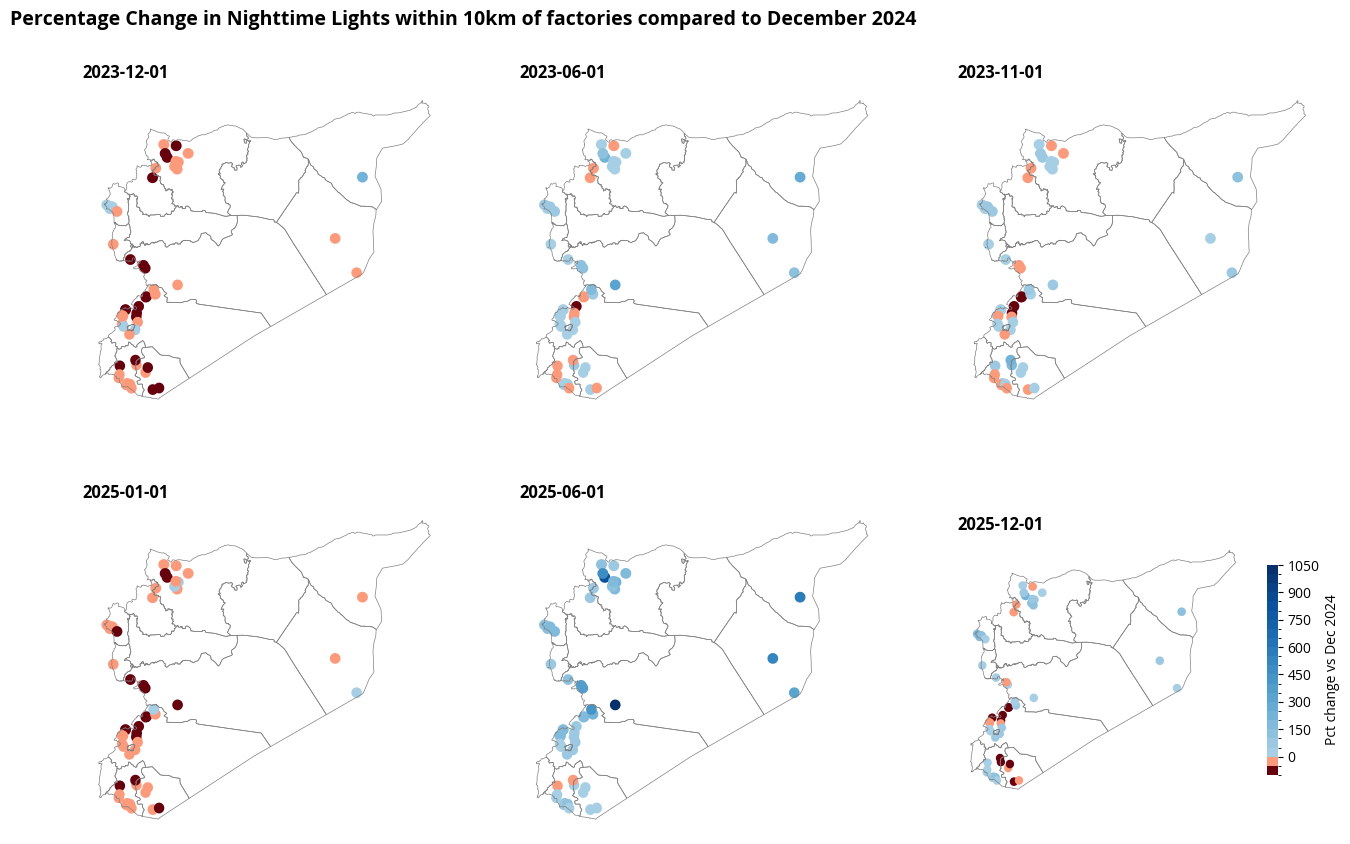

In [184]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

fig, ax = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(16, 10))
axs = ax.flatten()

vmin = monthly_drug_5km_moi["pc_change_dec2024"].min()
vmax = monthly_drug_5km_moi["pc_change_dec2024"].max()

# create 50-point bins across the range
bin_start = np.floor(vmin / 50.0) * 50.0
bin_end = np.ceil(vmax / 50.0) * 50.0
bins = np.arange(bin_start, bin_end + 50.0, 50.0)

# bin centers
bin_centers = (bins[:-1] + bins[1:]) / 2.0

# separate negative and positive centers
neg_centers = bin_centers[bin_centers < 0]
pos_centers = bin_centers[bin_centers > 0]

from matplotlib import cm

# sample distinct colors per bin: Reds for negatives (farther from 0 -> darker), blues for positives
nneg = len(neg_centers)
npos = len(pos_centers)

# avoid empty sampling
# For negatives we sample Reds from 1.0 down to 0.35 so larger-magnitude negatives (farther from 0)
# get darker red values. Positives remain sampled from Blues lighter->darker.
neg_colors = (
    cm.get_cmap("Reds")(np.linspace(1.0, 0.35, nneg)) if nneg > 0 else np.array([])
)
pos_colors = (
    cm.get_cmap("Blues")(np.linspace(0.35, 1.0, npos)) if npos > 0 else np.array([])
)

# assemble colors in the order of bin_centers
colors = []
neg_i = 0
pos_i = 0
for c in bin_centers:
    if c < 0:
        colors.append(tuple(neg_colors[neg_i]))
        neg_i += 1
    elif c > 0:
        colors.append(tuple(pos_colors[pos_i]))
        pos_i += 1
    else:
        colors.append((0.9, 0.9, 0.9, 1.0))

cmap = mpl.colors.ListedColormap(colors)
norm = mpl.colors.BoundaryNorm(bins, ncolors=len(colors), clip=True)

last_idx = len(months_of_interest) - 1
for idx, month in enumerate(months_of_interest):
    show_legend = idx == last_idx
    monthly_drug_5km_moi[monthly_drug_5km_moi["date"] == month].plot(
        column="pc_change_dec2024",
        legend=show_legend,
        legend_kwds={"label": "Pct change vs Dec 2024", "shrink": 0.6}
        if show_legend
        else None,
        ax=axs[idx],
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        norm=norm,
    )
    syria_adm1.boundary.plot(ax=axs[idx], color="grey", linewidth=0.5)
    axs[idx].set_title(month, loc="left")
    axs[idx].grid(False)
    axs[idx].set_axis_off()

fig.suptitle(
    "Percentage Change in Nighttime Lights within 10km of factories compared to December 2024",
    x=0.08,
    y=0.945,
    ha="left",
    fontsize=14,
    fontproperties=title_fp,
);